#TASK 1.1: Exploratory Data Analysis and Data Understanding

##Choosing a Dataset

#### (a) When and by whom the dataset was created

The dataset used for classification is UCI_Credit_Card which was updated by UCI Machine Learning and 1 collaborator and published on Kaggle.This dataset contains information on default payments, demographic factors, credit data, history of payment, and bill statements of credit card clients in Taiwan from April 2005 to September 2005.

#### (b) How and from where the dataset was accessed

The dataset was accessed from Kaggle:  
https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

#### (c) Alignment with United Nations Sustainable Development Goal (UNSDG)

This project aligns with SDG 8 – Decent Work and Economic Growth by promoting responsible lending and financial stability.

#### (d) List and brief description of all attributes
1. ID – Unique identification number for each customer record.
2. LIMIT_BAL – Amount of credit limit given to the customer, including individual and family/supplementary credit.
3.SEX – Gender of the customer
4. EDUCATION – Education level of the customer
5. MARRIAGE – Marital status
6. AGE – Age of the customer (in years).
7. PAY_0 to PAY_6 – Repayment status from September 2005 to April 2005
8. BILL_AMT1 to BILL_AMT6 – Amount of bill statement from September 2005 to April 2005
9. PAY_AMT1 to PAY_AMT6 – Amount paid from September 2005 to April 2005
10. default.payment.next.month – Target variable.
Indicates whether the customer will default on credit card payment next month.


### Two meaningful questions the dataset can answer.
1. How does a customer’s past repayment status (PAY_0 to PAY_6) affect the likelihood of default
2. Does the amount a customer pays each month (PAY_AMT1–PAY_AMT6) affect whether they will default on their credit card next month?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

#Load Dataset and Dataset information
df = pd.read_csv("UCI_Credit_Card.csv")
df.rename(columns={"default.payment.next.month":"default"}, inplace=True)
df.head()
print("Shape:", df.shape)
print("\nInfo:\n")
print(df.info())


Shape: (30000, 25)

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         30000 non-null  int64  
 1   LIMIT_BAL  30000 non-null  float64
 2   SEX        30000 non-null  int64  
 3   EDUCATION  30000 non-null  int64  
 4   MARRIAGE   30000 non-null  int64  
 5   AGE        30000 non-null  int64  
 6   PAY_0      30000 non-null  int64  
 7   PAY_2      30000 non-null  int64  
 8   PAY_3      30000 non-null  int64  
 9   PAY_4      30000 non-null  int64  
 10  PAY_5      30000 non-null  int64  
 11  PAY_6      30000 non-null  int64  
 12  BILL_AMT1  30000 non-null  float64
 13  BILL_AMT2  30000 non-null  float64
 14  BILL_AMT3  30000 non-null  float64
 15  BILL_AMT4  30000 non-null  float64
 16  BILL_AMT5  30000 non-null  float64
 17  BILL_AMT6  30000 non-null  float64
 18  PAY_AMT1   30000 non-null  float64
 19  PAY_AMT2   30000 no

In [ ]:
# count missing values in each column
print("\nZero values (treated as missing):")
print((df == 0).sum())

#Display duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()



Zero values (treated as missing):
ID               0
LIMIT_BAL        0
SEX              0
EDUCATION        0
MARRIAGE         0
AGE              0
PAY_0        14737
PAY_2        15730
PAY_3        15764
PAY_4        16455
PAY_5        16947
PAY_6        16286
BILL_AMT1     2008
BILL_AMT2     2506
BILL_AMT3     2870
BILL_AMT4     3195
BILL_AMT5     3506
BILL_AMT6     4020
PAY_AMT1      5249
PAY_AMT2      5396
PAY_AMT3      5968
PAY_AMT4      6408
PAY_AMT5      6703
PAY_AMT6      7173
default      23364
dtype: int64

Duplicate rows: 0


#1.2 Exploratory Data Analysis (EDA)

In [ ]:
#Exploratory Data Analysis (EDA):
#Perform data cleaning and compute summary statistics for the dataset.

#Treat 0 as missing
cols_with_zero_missing = ["EDUCATION", "MARRIAGE"]

for col in cols_with_zero_missing:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zero values treated as missing")
    df[col] = df[col].replace(0, np.nan)

#Get numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove("default")

#Fill missing numeric values with median
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"{col}: filled missing with median ({median_val:.2f})")

#Get categorical columns
categorical_cols = df.select_dtypes(include=['object','category']).columns.tolist()

#Fill missing categorical with mode
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"{col}: filled missing with mode ({mode_val})")

#Drop rows if target missing
df = df.dropna(subset=["default"]).reset_index(drop=True)

#Summary Statistics
print("\nSummary statistics:")
print(df.describe().round(2))

#Target variable distribution
print("\nTarget distribution:")
print(df["default"].value_counts())



EDUCATION: 0 zero values treated as missing
MARRIAGE: 0 zero values treated as missing

Summary statistics:
             ID   LIMIT_BAL       SEX  EDUCATION  MARRIAGE       AGE  \
count  30000.00    30000.00  30000.00   30000.00  30000.00  30000.00   
mean   15000.50   167484.32      1.60       1.85      1.56     35.49   
std     8660.40   129747.66      0.49       0.79      0.52      9.22   
min        1.00    10000.00      1.00       1.00      1.00     21.00   
25%     7500.75    50000.00      1.00       1.00      1.00     28.00   
50%    15000.50   140000.00      2.00       2.00      2.00     34.00   
75%    22500.25   240000.00      2.00       2.00      2.00     41.00   
max    30000.00  1000000.00      2.00       6.00      3.00     79.00   

          PAY_0     PAY_2     PAY_3     PAY_4  ...  BILL_AMT4  BILL_AMT5  \
count  30000.00  30000.00  30000.00  30000.00  ...   30000.00   30000.00   
mean      -0.02     -0.13     -0.17     -0.22  ...   43262.95   40311.40   
std        1.12

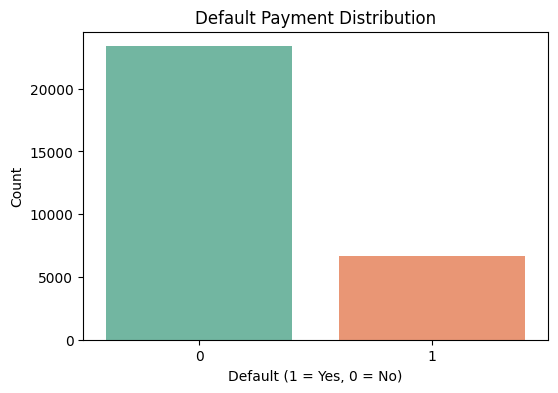

In [ ]:
#Use visualizations and charts to summarize, explore, and understand the data.
# 1) Countplot for target variable
plt.figure(figsize=(6,4))
sns.countplot(x="default", data=df, palette="Set2")
plt.title("Default Payment Distribution")
plt.xlabel("Default (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()


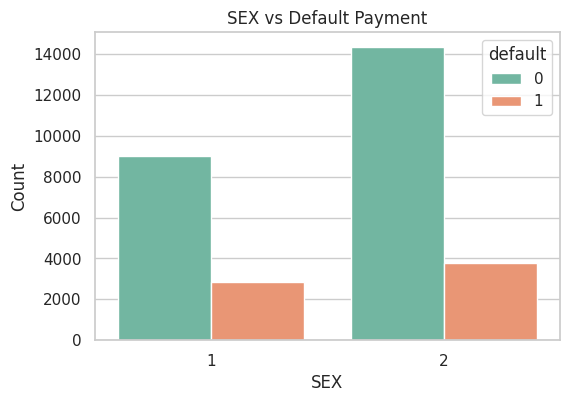

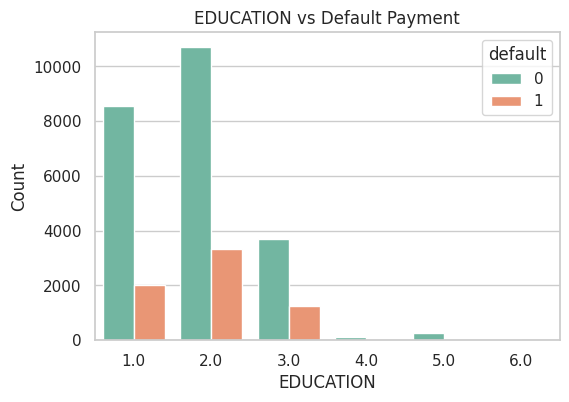

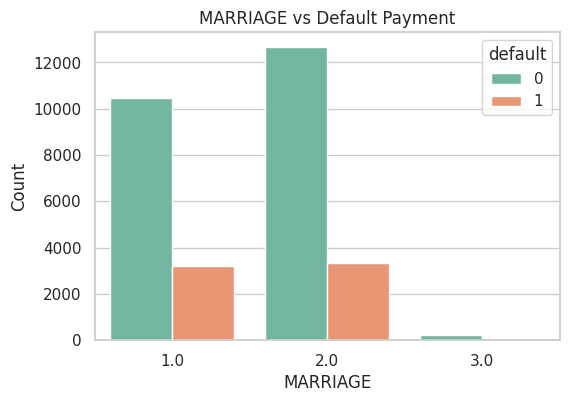

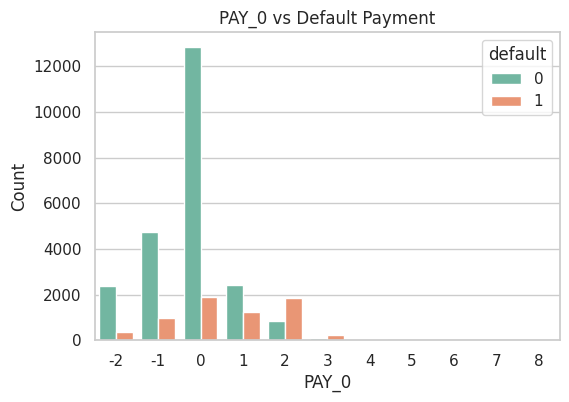

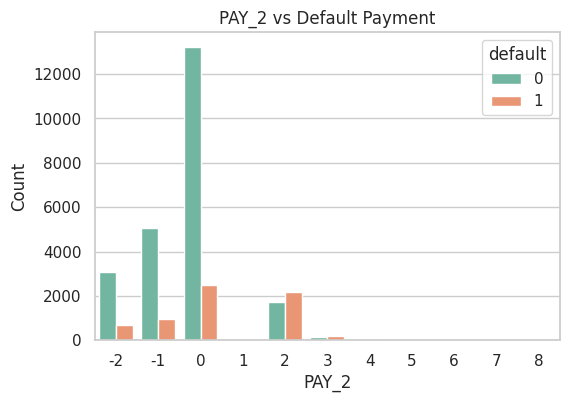

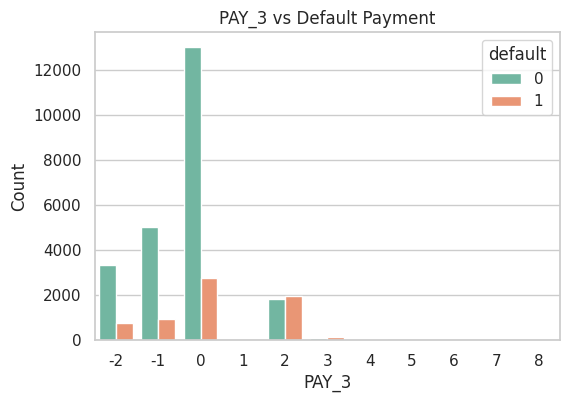

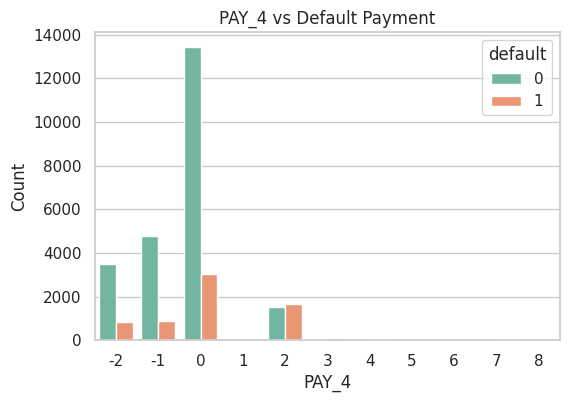

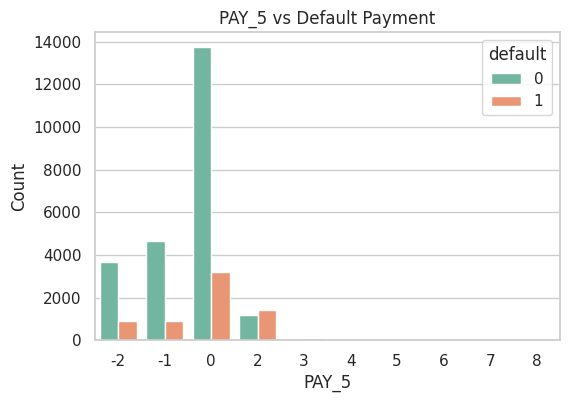

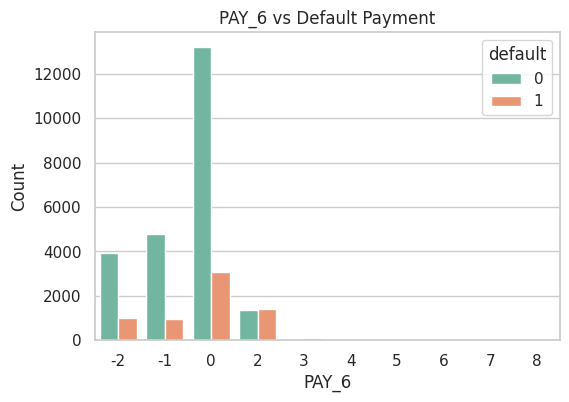

In [ ]:
#Categorical Features vs Target
# List of categorical features
target = 'default'
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

# Plot categorical features vs target
for col in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue=target, data=df, palette='Set2')
    plt.title(f'{col} vs Default Payment')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

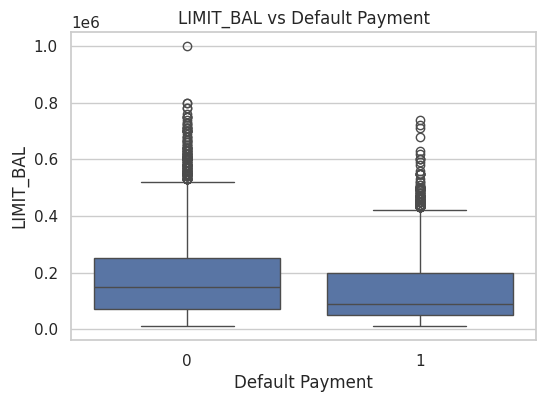

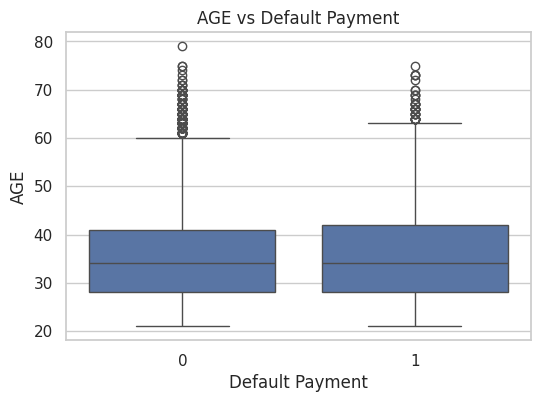

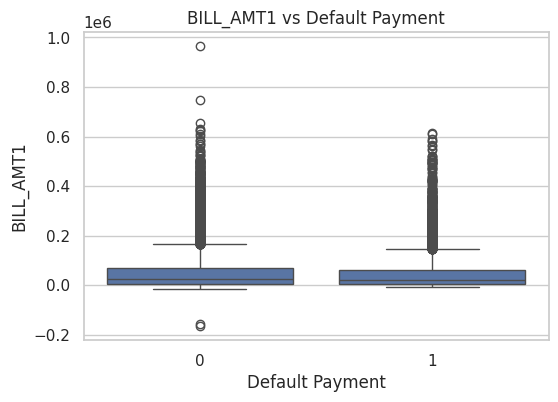

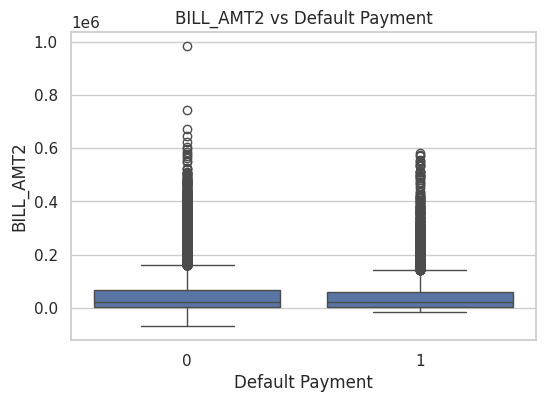

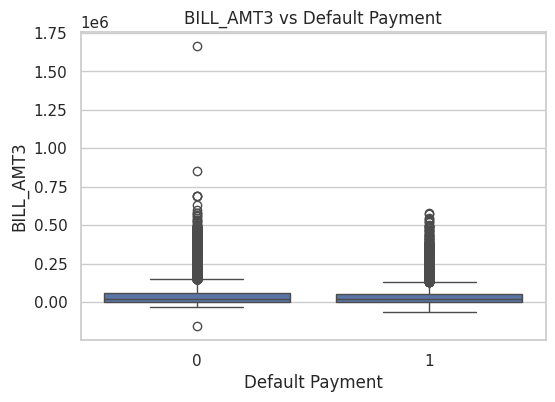

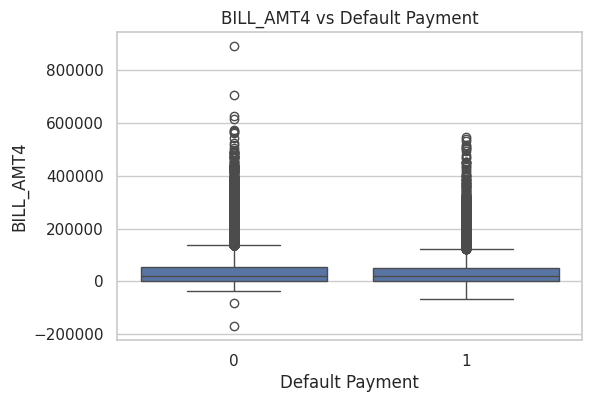

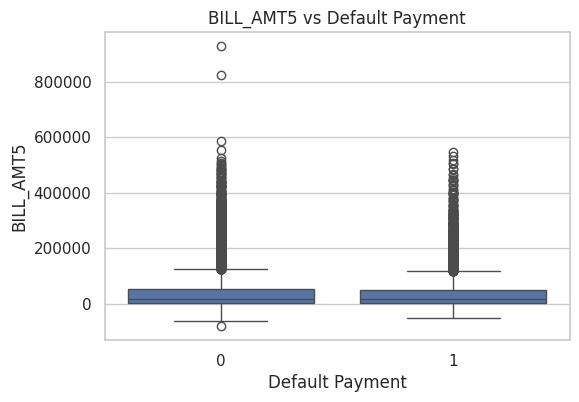

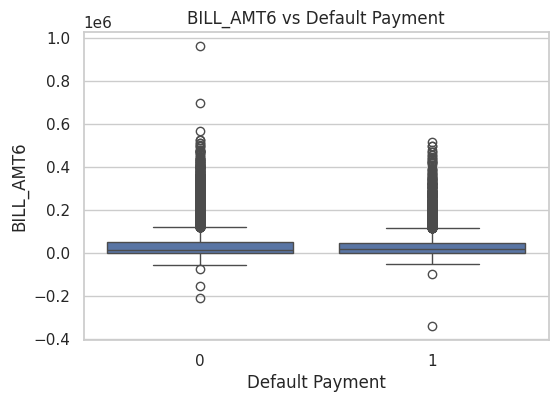

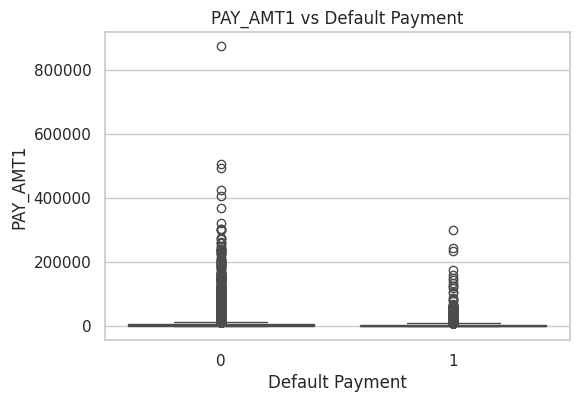

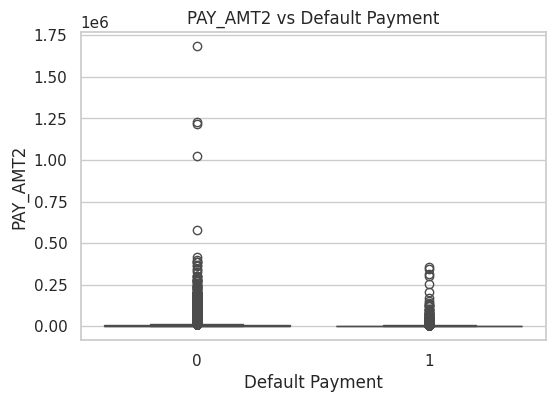

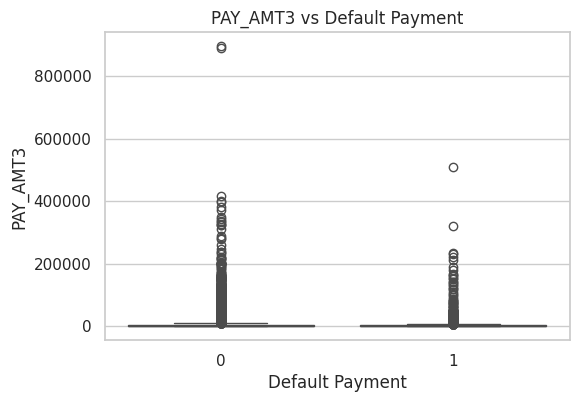

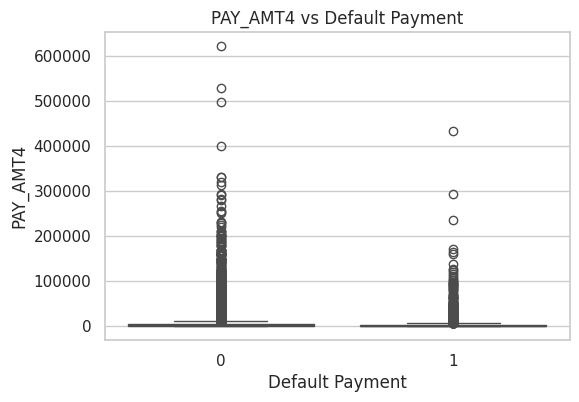

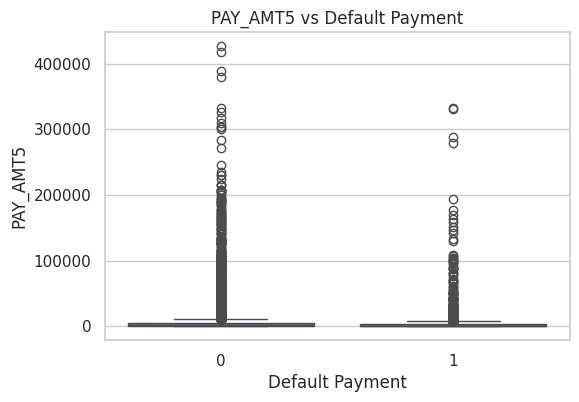

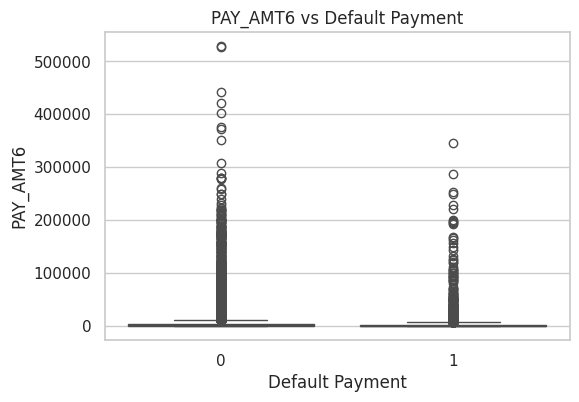

In [ ]:
#Numerical Features vs Target
# List of categorical features
target = 'default'
numerical_features = ['LIMIT_BAL', 'AGE', 'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
                      'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']

for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=target, y=col, data=df)
    plt.title(f'{col} vs Default Payment')
    plt.xlabel('Default Payment')
    plt.ylabel(col)
    plt.show()

In [ ]:
# Encode all categorical variables for correlation analysis
df_encoded = df.copy()
label_encoders = {}

for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

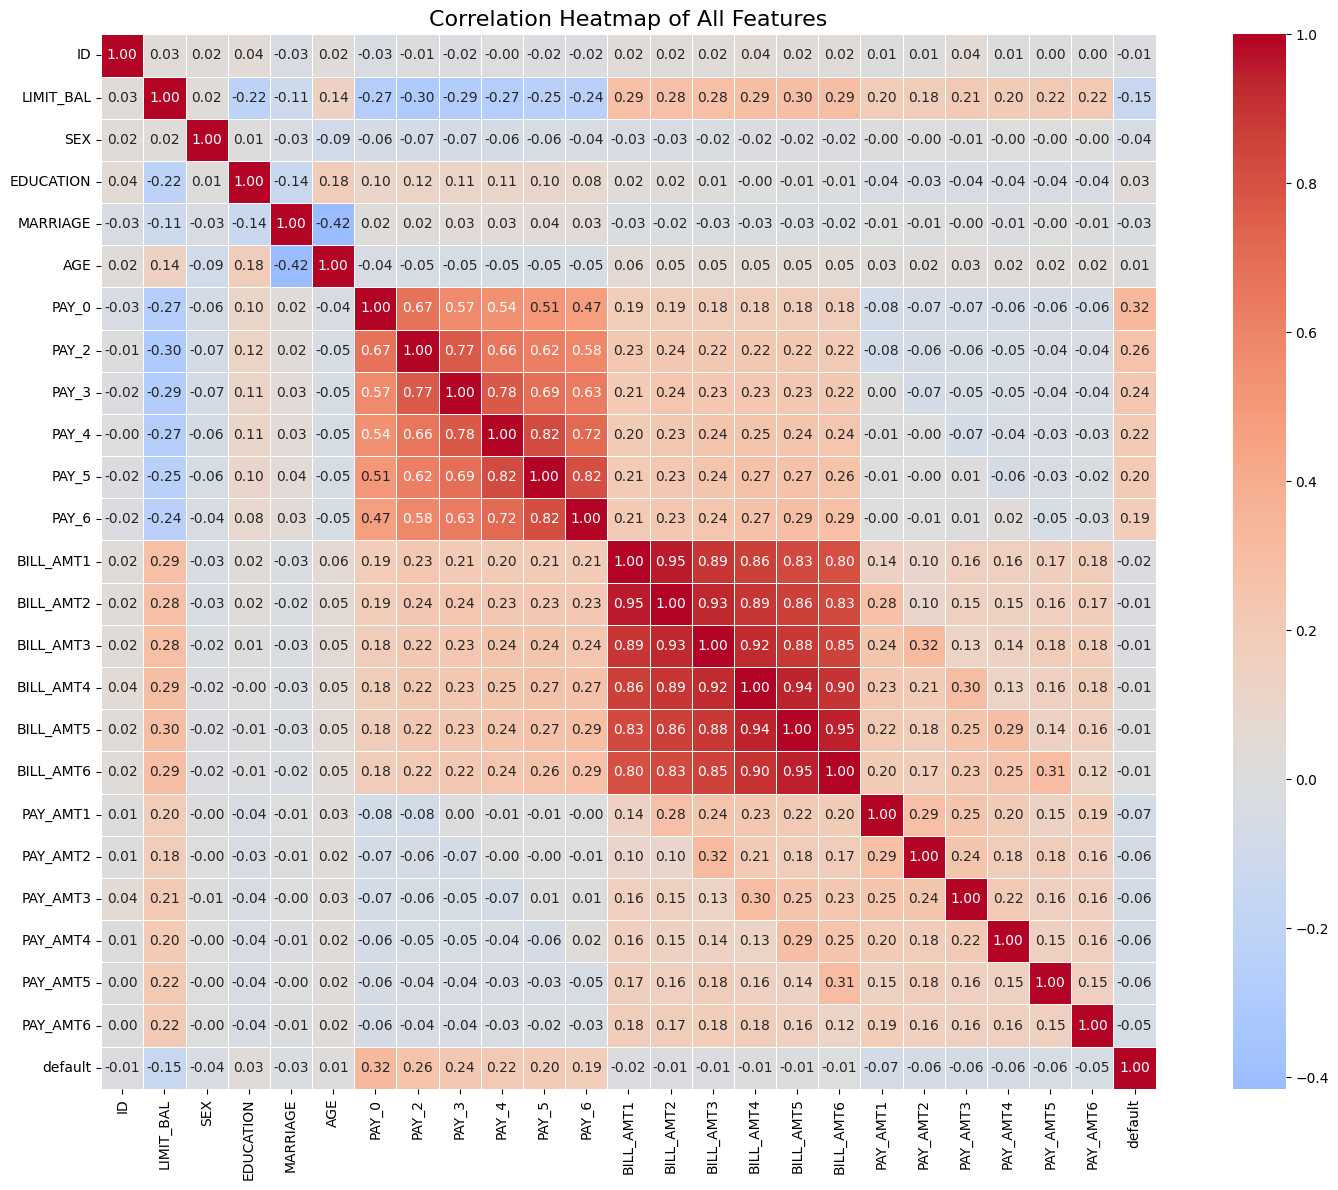

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(16, 12))
correlation_matrix = df_encoded.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,        # show correlation numbers
    fmt='.2f',         # 2 decimal places
    cmap='coolwarm',   # red-blue color map
    center=0,          # center colormap at 0
    square=True,       # make cells square
    linewidths=0.5     # grid lines
)

plt.title('Correlation Heatmap of All Features', fontsize=16)
plt.tight_layout()
plt.show()

# Task 2: Build a Neural Network Model

1. from sklearn.model_selection import train_test_split
2. from sklearn.preprocessing import StandardScaler
3. from sklearn.neural_network import MLPClassifier
4. from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix



In [ ]:
# Define target column
target = 'default'

# Features & target
X = df.drop(columns=[target])
y = df[target]

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [ ]:
# Build and train the Neural Network
nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

nn_model.fit(X_train, y_train)
print('Neural Network model trained successfully.')



Neural Network model trained successfully.


Train Accuracy: 0.8206666666666667
Test Accuracy: 0.8155

=== Neural Network - Testing Set Performance ===
Precision for Test set: 0.6348167539267016
Recall for Test set: 0.3693830921553694
F1 Score for Test set: 0.46701974000962926

=== Neural Network - Training Set Performance ===
Precision for Train set: 0.6596678157317455
Recall for Train set: 0.39545369152733423
F1 Score for Train set: 0.4944796805261922


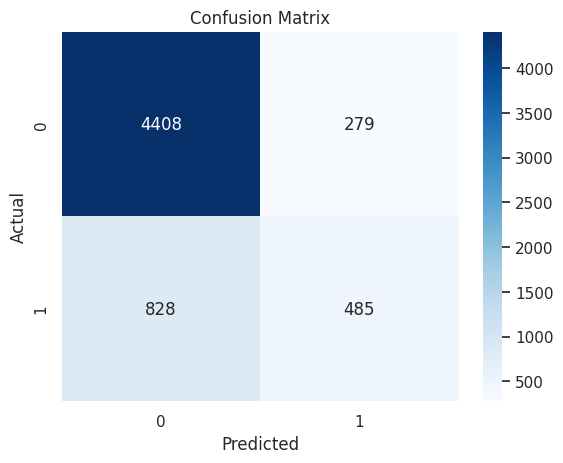

In [ ]:
# Predictions
y_train_pred = nn_model.predict(X_train)
y_test_pred = nn_model.predict(X_test)

# Metrics
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print()

print('=== Neural Network - Testing Set Performance ===')
print("Precision for Test set:", precision_score(y_test, y_test_pred))
print("Recall for Test set:", recall_score(y_test, y_test_pred))
print("F1 Score for Test set:", f1_score(y_test, y_test_pred))
print()

print('=== Neural Network - Training Set Performance ===')
print("Precision for Train set:", precision_score(y_train, y_train_pred))
print("Recall for Train set:", recall_score(y_train, y_train_pred))
print("F1 Score for Train set:", f1_score(y_train, y_train_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# TASK 3: Build Primary Model


### 3.1 Split Dataset into Training and Testing Sets

In [ ]:
# Data already split above
print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples: {X_test.shape[0]}')
print(f'Train/Test split ratio: 80/20 (stratified)')

Training samples: 24000
Testing samples: 6000
Train/Test split ratio: 80/20 (stratified)


### 3.2 Build at least two different machine learning models (excluding neural network)

1. from sklearn.ensemble import RandomForestClassifier
2. from sklearn.linear_model import LogisticRegression
3. from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

##Logistic Regression Classifier

In [ ]:
#Logistic Regression

# Initialize model
logreg = LogisticRegression(random_state=42)
# Train
logreg.fit(X_train, y_train)

# Predictions
y_train_pred_lr = logreg.predict(X_train)
y_test_pred_lr = logreg.predict(X_test)

# set evaluation
print('=== Logistic Regression Training Set ===')
print(f'Accuracy:  {accuracy_score(y_train, y_train_pred_lr):.4f}')
print(f'Precision: {precision_score(y_train, y_train_pred_lr, average="weighted"):.4f}')
print(f'Recall:    {recall_score(y_train, y_train_pred_lr, average="weighted"):.4f}')
print(f'F1-Score:  {f1_score(y_train, y_train_pred_lr, average="weighted"):.4f}')

print('\n=== Logistic Regression Test Set ===')
print(f'Accuracy:  {accuracy_score(y_test, y_test_pred_lr):.4f}')
print(f'Precision: {precision_score(y_test, y_test_pred_lr, average="weighted"):.4f}')
print(f'Recall:    {recall_score(y_test, y_test_pred_lr, average="weighted"):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_test_pred_lr, average="weighted"):.4f}')

print('\nLOgistic Regression:')
print(classification_report(y_test, y_test_pred_lr))


=== Logistic Regression Training Set ===
Accuracy:  0.8109
Precision: 0.7960
Recall:    0.8109
F1-Score:  0.7725

=== Logistic Regression Test Set ===
Accuracy:  0.8098
Precision: 0.7915
Recall:    0.8098
F1-Score:  0.7712

LOgistic Regression:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.69      0.24      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



##Random Forest Classifier

In [ ]:
#Random Forest
# Initialize model
rf= RandomForestClassifier(random_state=42)

# Train
rf.fit(X_train, y_train)

# Predictions
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

#set evaluation
print('=== Random Forest Training Set ===')
print(f'Accuracy:  {accuracy_score(y_train, y_train_pred_rf):.4f}')
print(f'Precision: {precision_score(y_train, y_train_pred_rf, average="weighted"):.4f}')
print(f'Recall:    {recall_score(y_train, y_train_pred_rf, average="weighted"):.4f}')
print(f'F1-Score:  {f1_score(y_train, y_train_pred_rf, average="weighted"):.4f}')

print('\n=== Random Forest Test Set ===')
print(f'Accuracy:  {accuracy_score(y_test, y_test_pred_rf):.4f}')
print(f'Precision: {precision_score(y_test, y_test_pred_rf, average="weighted"):.4f}')
print(f'Recall:    {recall_score(y_test, y_test_pred_rf, average="weighted"):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_test_pred_rf, average="weighted"):.4f}')
print('\n Random Forest report :')
print(classification_report(y_test, y_test_pred_rf))


=== Random Forest Training Set ===
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000

=== Random Forest Test Set ===
Accuracy:  0.8177
Precision: 0.7992
Recall:    0.8177
F1-Score:  0.7976

 Random Forest report :
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4687
           1       0.65      0.37      0.47      1313

    accuracy                           0.82      6000
   macro avg       0.74      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



##Confusion Matrix

####from sklearn.metrics import confusion_matrix

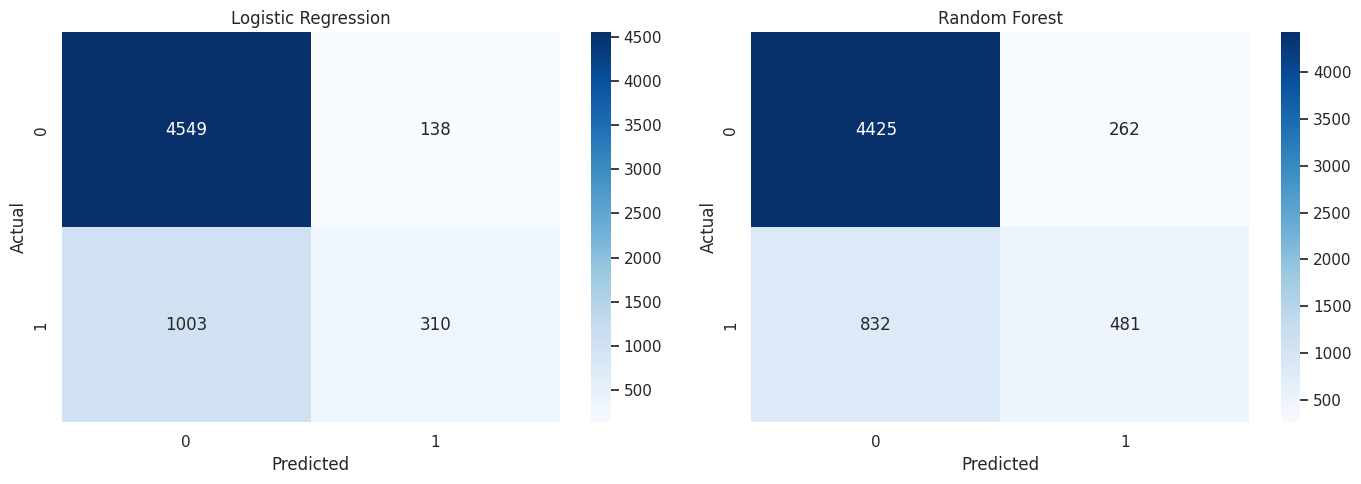

In [ ]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression confusion matrix
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

#TASK 4: Hyper-parameter Optimization with Cross-Validation

1. from sklearn.model_selection import GridSearchCV
2. from sklearn.linear_model import LogisticRegression
3. from sklearn.tree import DecisionTreeClassifier
4. from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
# Logistic Regression Hyperparameter Grid
param_lr = {
    'C':[0.01,0.1,1,10],
    'penalty':['l2']
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=500),
                       param_lr, cv=5, scoring='accuracy')

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
print("Best Logistic Regression params:", grid_lr.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_lr.best_score_:.4f}")


Best Logistic Regression params: {'C': 1, 'penalty': 'l2'}
Best Cross-Validation Accuracy: 0.8100


In [ ]:
# Random Forest Hyperparameter Grid
param_rf = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_rf, cv=5, scoring='accuracy')

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print("Best Random Forest params:", grid_rf.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_lr.best_score_:.4f}")


Best Random Forest params: {'max_depth': 10, 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.8100


#TASK 5:Feature Selection

1. from sklearn.feature_selection import SelectKBest, f_classif
2. from sklearn.metrics import accuracy_score
3. from sklearn.linear_model import LogisticRegression
4. from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Choose top k features (e.g., k=15)
k = 15
selector = SelectKBest(score_func=f_classif, k=k)

# Fit on training data
X_selected = selector.fit_transform(X_train, y_train)

# Get selected feature names
selected_features = X_train.columns[selector.get_support()] if hasattr(X_train, 'columns') else df.drop(columns=[target]).columns[selector.get_support()]
print(f"Top {k} selected features:")
print(selected_features)

# Transform both train and test sets
X_train_selected = selector.transform(X_train)
X_test_selected  = selector.transform(X_test)

# Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_selected, y_train)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_selected, y_train)

# Evaluate test set
y_test_pred_lr = lr.predict(X_test_selected)
y_test_pred_rf = rf.predict(X_test_selected)

print("Logistic Regression Test Accuracy:", accuracy_score(y_test, y_test_pred_lr))
print("Random Forest Test Accuracy:", accuracy_score(y_test, y_test_pred_rf))


Top 15 selected features:
Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4',
       'PAY_5', 'PAY_6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4',
       'PAY_AMT5', 'PAY_AMT6'],
      dtype='object')
Logistic Regression Test Accuracy: 0.808
Random Forest Test Accuracy: 0.8126666666666666


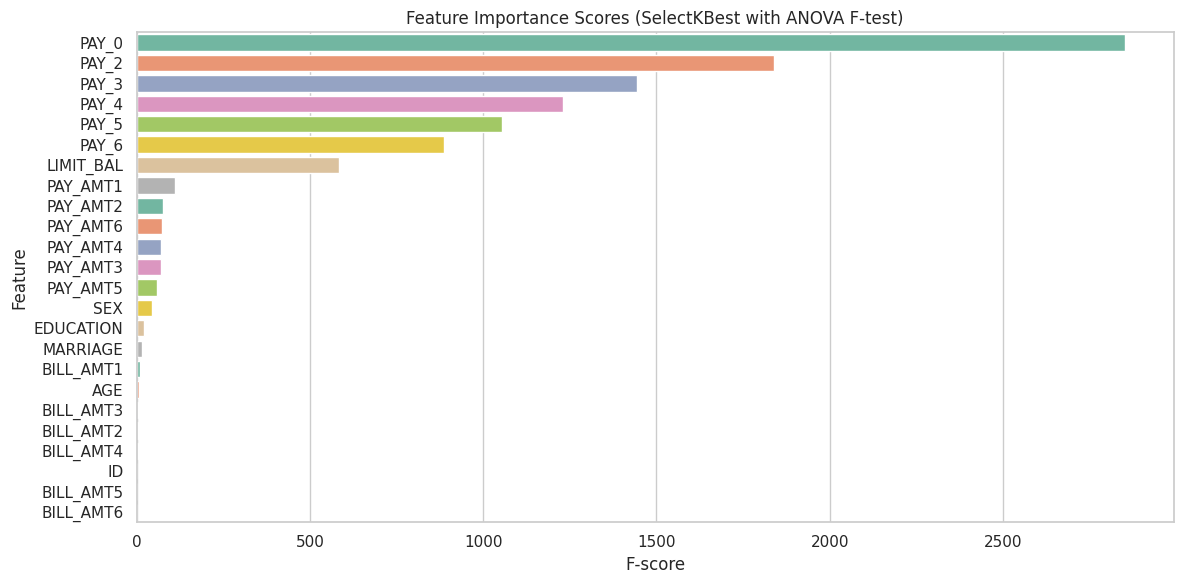

In [ ]:
feature_scores = selector.scores_
feature_names = df.drop(columns=[target]).columns
scores_df = pd.DataFrame({
    'Feature': feature_names,
    'F_score': feature_scores
}).sort_values(by='F_score', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x='F_score', y='Feature', data=scores_df, palette='Set2')
plt.title('Feature Importance Scores (SelectKBest with ANOVA F-test)')
plt.xlabel('F-score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#TASK 6:Final Models and Comparative Analysis

1. from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
2. from sklearn.linear_model import LogisticRegression
3. from sklearn.ensemble import RandomForestClassifier

In [ ]:

# Predictions on test set
y_pred_lr = lr.predict(X_test_selected)
y_pred_rf = rf.predict(X_test_selected)


# Logistic Regression metrics
print("=== Logistic Regression ===")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-Score :", f1_score(y_test, y_pred_lr))
print("\n")

# Random Forest metrics
print("=== Random Forest ===")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-Score :", f1_score(y_test, y_pred_rf))


=== Logistic Regression ===
Accuracy : 0.808
Precision: 0.6977886977886978
Recall   : 0.2162985529322163
F1-Score : 0.3302325581395349


=== Random Forest ===
Accuracy : 0.8126666666666666
Precision: 0.6185696361355082
Recall   : 0.37547600913937546
F1-Score : 0.46729857819905213


In [ ]:
# Final Comparison Table
final_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression (Model A)',
        'Random Forest Classifier (Model B)'
    ],
    'Features': [
        f'Selected ({len(selected_features)})',
        f'Selected ({len(selected_features)})'
    ],
    'Accuracy': [
        round(accuracy_score(y_test,y_pred_lr), 4),
        round(accuracy_score(y_test, y_pred_rf), 4)
    ],
    'Precision': [
        round(precision_score(y_test, y_pred_lr, average='weighted'), 4),
        round(precision_score(y_test, y_pred_rf, average='weighted'), 4)
    ],
    'Recall': [
        round(recall_score(y_test, y_pred_lr, average='weighted'), 4),
        round(recall_score(y_test, y_pred_rf, average='weighted'), 4)
    ],
    'F1-Score': [
        round(f1_score(y_test, y_pred_lr, average='weighted'), 4),
        round(f1_score(y_test, y_pred_rf, average='weighted'), 4)
    ]
})

print(' Comparison of Final Classification Models ')
print(final_comparison.to_string(index=False))

 Comparison of Final Classification Models 
                             Model      Features  Accuracy  Precision  Recall  F1-Score
     Logistic Regression (Model A) Selected (15)    0.8080     0.7901  0.8080    0.7659
Random Forest Classifier (Model B) Selected (15)    0.8127     0.7934  0.8127    0.7946


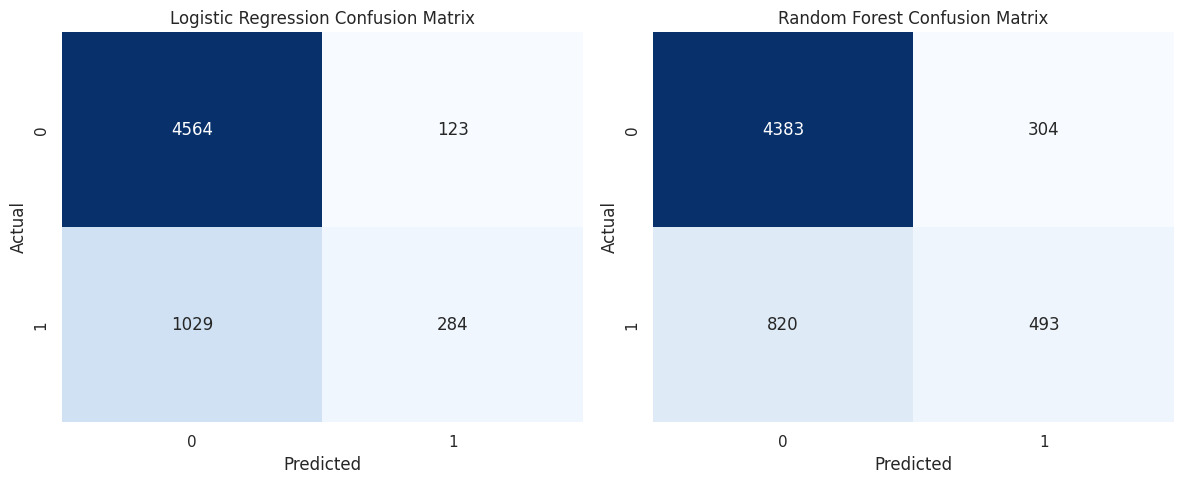

In [ ]:
# Confusion matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(12, 5))

# Logistic Regression CM
plt.subplot(1, 2, 1)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Random Forest CM
plt.subplot(1, 2, 2)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

